# CloudDiffusion: Inference and Visualization

This notebook loads a trained model and performs inference on the validation set (the last 10% of the data). It visualizes the **Input Sequence**, the **Predicted Frame**, and the **Original Ground Truth**.

In [1]:
import sys
import os
from pathlib import Path

# ---------------------------------------------------------------------------
# ROBUST PATH SETUP: Ensure the 'src' directory is importable
# ---------------------------------------------------------------------------
# Get the absolute path to the project root (one level up from /notebooks)
project_root = str(Path(os.getcwd()).parent.absolute())

if project_root not in sys.path:
    # insert at index 0 to give it highest priority
    sys.path.insert(0, project_root)

print(f"Project root added to sys.path: {project_root}")

import torch
import yaml
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, Subset

# Now import from src
try:
    from src.dataset import Clouds
    from src.models.convlstm import ConvLSTM
    from src.utils import ssim, calculate_csi
    print("Successfully imported modules from 'src'!")
except ImportError as e:
    print(f"ERROR: Could not import from 'src'. Check your directory structure.")
    print(f"Current sys.path: {sys.path}")
    raise e

Project root added to sys.path: /home/imaayush/code/cloudDiffusion
Successfully imported modules from 'src'!


## 1. Setup and Config

In [2]:
# Load config
config_path = os.path.join(project_root, 'config.yaml')
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint_path = os.path.join(project_root, 'checkpoints', 'model_epoch_10.pt') # Adjust as needed
T = config['data']['T']
print(f"Using device: {device}")

Using device: cuda


## 2. Load Data (Validation Split)

In [3]:
manifest_path = os.path.join(project_root, 'data', 'manifest.json')
full_dataset = Clouds(manifest_path=manifest_path, T=T)

# Get the last 10% of the dataset (Validation set)
val_size = int(config['data']['train_split'] * len(full_dataset))
indices = list(range(val_size, len(full_dataset)))
val_dataset = Subset(full_dataset, indices)

print(f"Validation samples: {len(val_dataset)}")
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

Validation samples: 115


## 3. Load Model

In [4]:
model = ConvLSTM(
    input_dim=1, 
    hidden_dim=config['model']['hidden_dim'], 
    kernel_size=config['model']['kernel_size'], 
    num_layers=config['model']['num_layers']
).to(device)

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(f"Loaded model from {checkpoint_path} (Epoch {checkpoint['epoch']})")
else:
    print(f"WARNING: Checkpoint not found at {checkpoint_path}. Using uninitialized model.")

Loaded model from /home/imaayush/code/cloudDiffusion/checkpoints/model_epoch_10.pt (Epoch 10)


## 4. Run Inference and Visualize

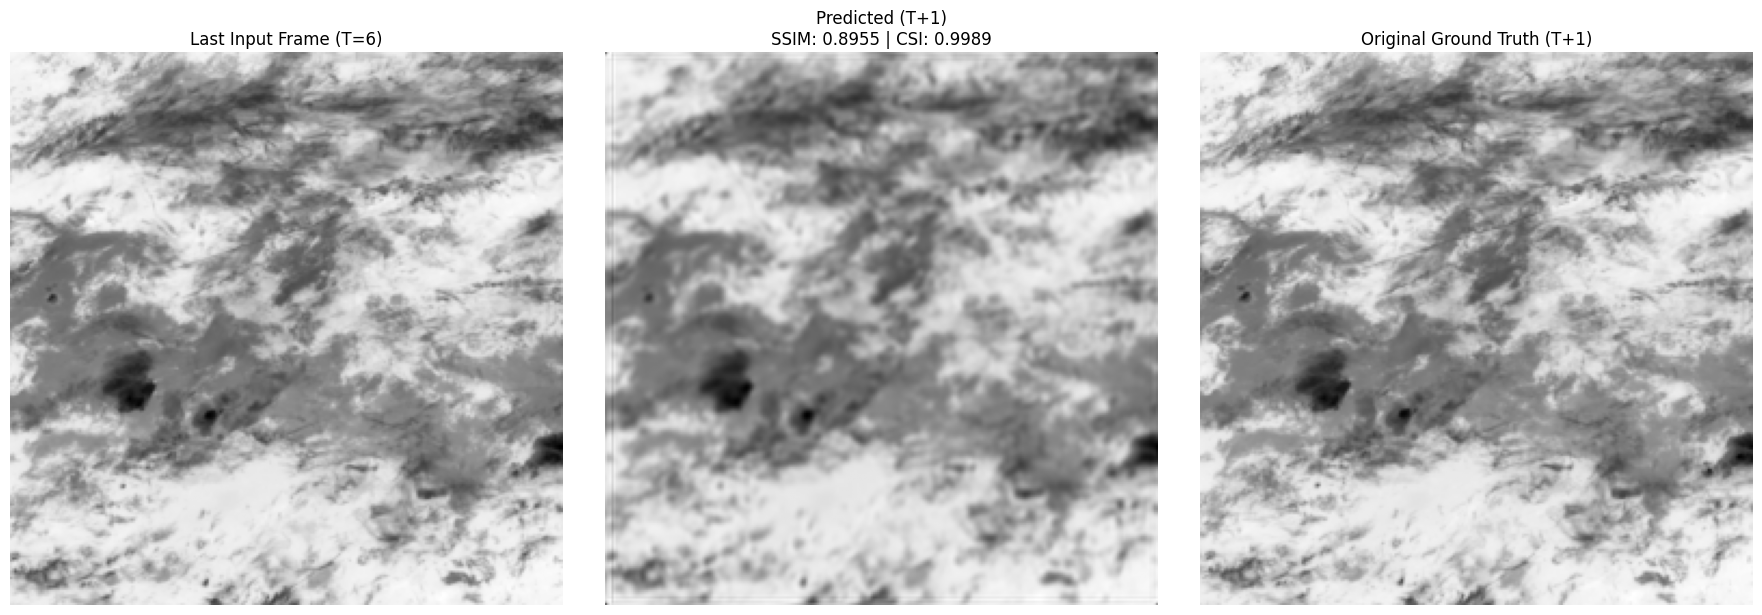

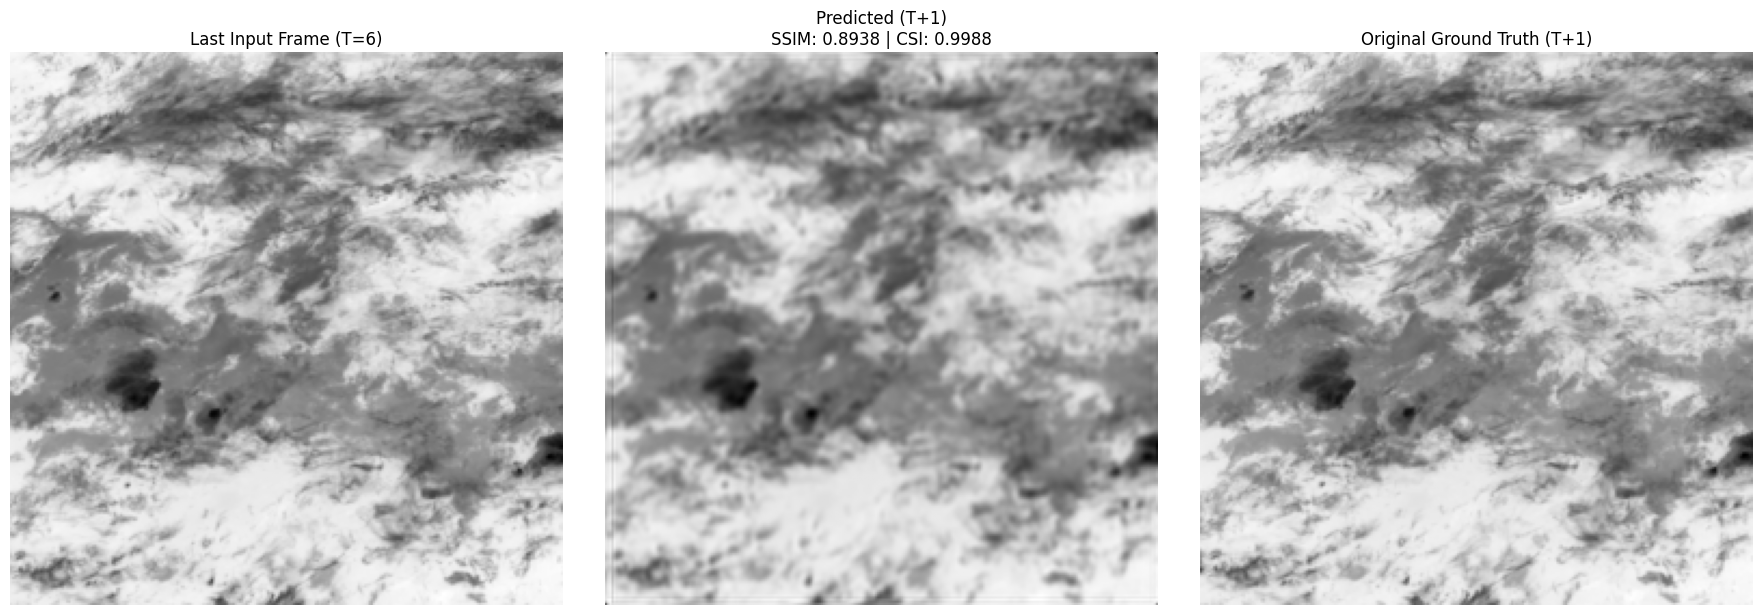

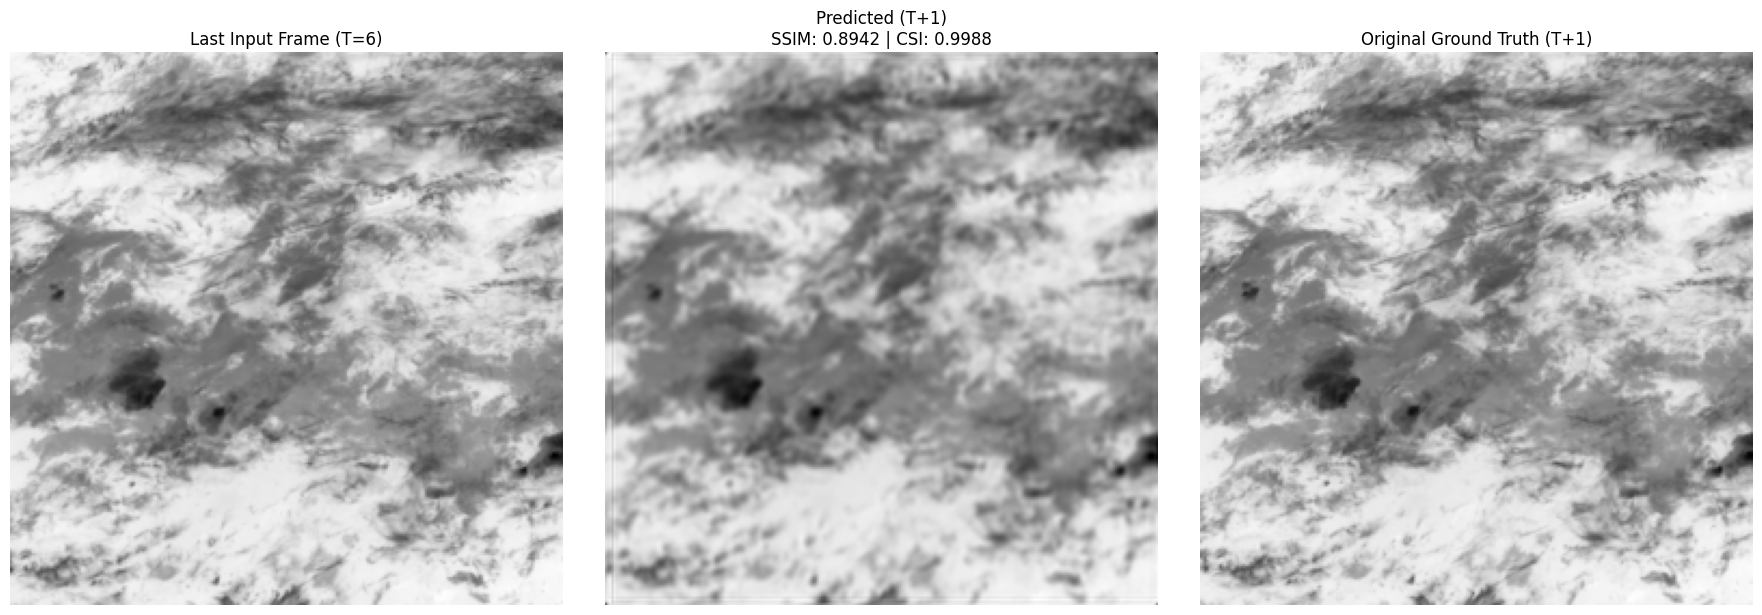

In [5]:
def show_inference(model, loader, num_samples=3):
    model.eval()
    with torch.no_grad():
        for i, (inputs, targets) in enumerate(loader):
            if i >= num_samples: break
            
            # Inference
            model_input = inputs.unsqueeze(2).to(device) # [B, T, 1, H, W]
            pred = model(model_input).cpu().squeeze()    # [H, W]
            target = targets.squeeze()                   # [H, W]
            
            # Metrics
            # ssim expects [B, C, H, W]
            s_score = ssim(pred.unsqueeze(0).unsqueeze(0), target.unsqueeze(0).unsqueeze(0)).item()
            c_score = calculate_csi(pred.unsqueeze(0).unsqueeze(0), target.unsqueeze(0).unsqueeze(0)).item()
            
            # Plotting
            fig, axes = plt.subplots(1, 3, figsize=(18, 6))
            
            # Last Input Frame
            axes[0].imshow(inputs[0, -1].cpu().numpy(), cmap='gray')
            axes[0].set_title(f"Last Input Frame (T={T})")
            axes[0].axis('off')
            
            # Predicted Frame
            axes[1].imshow(pred.numpy(), cmap='gray')
            axes[1].set_title(f"Predicted (T+1)\nSSIM: {s_score:.4f} | CSI: {c_score:.4f}")
            axes[1].axis('off')
            
            # Ground Truth
            axes[2].imshow(target.cpu().numpy(), cmap='gray')
            axes[2].set_title("Original Ground Truth (T+1)")
            axes[2].axis('off')
            
            plt.tight_layout()
            plt.show()

show_inference(model, val_loader, num_samples=3)